# Machine Learning Project 1

In [2]:
import glob
import pandas as pd

dataFiles = glob.glob('../Machine-Learning-Project-1/heart.csv')

data = []

# extract files
for file in dataFiles:
    # convert file to dataframe and add it to the list
    data.append(pd.read_csv(file, sep = ','))
    
# concatenate all the dataframes into one
data = pd.concat(data)

# display the data
data


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


Train Accuracy: 0.8682926829268293
Validation Accuracy: 0.8097560975609757
Test Accuracy: 0.8097560975609757

Predicted class labels:
 [0 1 1 1 0 1 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1
 0 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 0 1 1 0 0 1 1 1 0 0 1
 1 1 1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 0
 1 0 1 1 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 0 0
 0 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 1 1 0 0 0 1 1 0 0
 0 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0]

True class labels:
 [0 1 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 1
 0 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0
 1 1 0 0 1 0 0 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 1 1 1 0 1 0 0 1 1 0 0
 1 0 1 1 1 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 0
 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 0 1 1 1 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0
 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0]

Classific

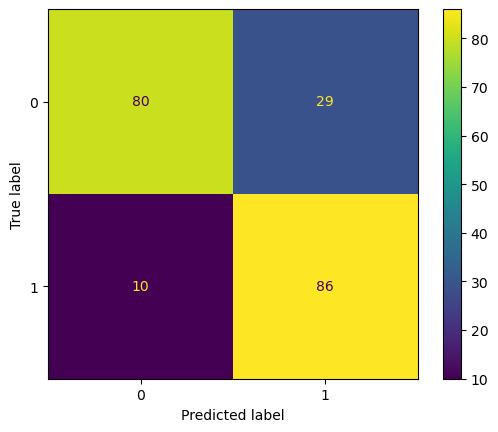

In [14]:
from sklearn.model_selection import train_test_split
X = data.drop(columns=['target'])
y = data["target"]

# split the data into training and test sets, 80% training, 20% test
tempTrainX, testX, tempTrainY, testY = train_test_split(X, y, test_size = 0.2, random_state = 1)
# split training into validation (60% test, 20% validation, 20% test)
trainX, validationX, trainY, validationY = train_test_split(tempTrainX, tempTrainY, test_size = 0.25, random_state = 1)

# standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit on training features
scaledTrainX = scaler.fit_transform(trainX)

# transform validation and test
scaledValidationX = scaler.transform(validationX)
scaledTestX = scaler.transform(testX)

# logistic regression used as baseline model
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression()
baseline.fit(scaledTrainX, trainY)

# predictions
trainPrediction = baseline.predict(scaledTrainX)
validationPrediction = baseline.predict(scaledValidationX)
testPrediction = baseline.predict(scaledTestX)

# MSE and MAE don't apply here, use accuracy score
from sklearn.metrics import accuracy_score

print("Train Accuracy:", accuracy_score(trainY, trainPrediction))
print("Validation Accuracy:", accuracy_score(validationY, validationPrediction))
print("Test Accuracy:", accuracy_score(testY, testPrediction))

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# print predicted and true class labels
print('\nPredicted class labels:\n', testPrediction)
print('\nTrue class labels:\n', testY.to_numpy())

# print quality metrics
print('\nClassification Report:\n\n', classification_report(testY, testPrediction))

confusionMatrix = confusion_matrix(testY, testPrediction)
display = ConfusionMatrixDisplay(confusion_matrix=confusionMatrix)
display.plot()